In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
t=2    Caps=[9, 9, 10, 10]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[8, 8, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[7, 5, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[5, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[3, 3, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 2, 3]
True
t=7    Caps=[2, -1, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [ ]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=True, reject_bias = 0.75, gamma = 0.98, epsilon_decay_steps=10000)

In [6]:
reward_history, monotonicity_violations = agent.train(num_episodes=1500)

Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 24
  Systematic monotonicity (Episode 1): C_k: 51.0%, t: 37.8%, r: 98.0%, q: 54.0%, mixed: 87.5%
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 20
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 18
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 17
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 17
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 20
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 17
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 24
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 15
Keine zusammenhängende Kapazität mehr verfügbar. Episode wird beendet bei Zeitschritt. 14
Keine 

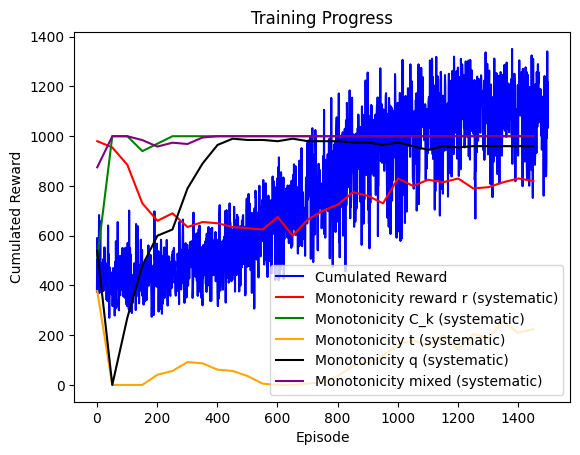

In [7]:
episodes = [x[0] for x in monotonicity_violations]
mono_c   = [x[1] * 1000 for x in monotonicity_violations]
mono_t   = [x[2] * 1000 for x in monotonicity_violations]
mono_r   = [x[3] * 1000 for x in monotonicity_violations]
mono_q   = [x[4] * 1000 for x in monotonicity_violations]
mono_mixed = [x[5] * 1000 for x in monotonicity_violations]

plt.plot(reward_history, color="blue", label="Cumulated Reward")
plt.plot(episodes, mono_r,  color="red",    label="Monotonicity reward r (systematic)")
plt.plot(episodes, mono_c, color="green",  label="Monotonicity C_k (systematic)")
plt.plot(episodes, mono_t, color="orange", label="Monotonicity t (systematic)")
plt.plot(episodes, mono_q, color="black",   label="Monotonicity q (systematic)")
plt.plot(episodes, mono_mixed, color="purple", label="Monotonicity mixed (systematic)")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

## Beispiel-Durchlauf des trainierten Agenten

In [8]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset()
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Aktion gewählt: 0
t=2    Caps=[10, 10, 10, 10]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=3    Caps=[10, 10, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=4    Caps=[10, 10, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=5    Caps=[8, 9, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=6    Caps=[8, 9, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=7    Caps=[8, 9, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=8    Caps=[8, 9, 10, 10]  r=13.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=9    Caps=[8, 9, 10, 10]  r=77.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=10   Caps=[8, 9, 9, 9]  r=8.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=11   Caps=[8, 9, 9, 9]  r=25.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion ge